# Day 5 - Week 1 Integrated Mini Notebook

## Objective

This notebook demonstrates a complete data analysis workflow using NumPy, Pandas, and Matplotlib. The dataset is loaded, cleaned, analyzed, and visualized.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


## Loading the Dataset

The Titanic dataset is loaded into a Pandas DataFrame.

In [2]:
df = pd.read_csv("tested.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## Cleaning the Dataset

Missing values are handled before analysis. The Age and Fare columns are filled with their mean values, and the Cabin column is removed because it contains many missing values.

In [4]:
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Fare"] = df["Fare"].fillna(df["Fare"].mean())

df.drop(columns=["Cabin"], inplace=True)

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## NumPy Analysis

NumPy is used to calculate basic statistics from the Age column.

In [5]:
ages = df["Age"].to_numpy()

print("Average Age:", np.mean(ages))
print("Minimum Age:", np.min(ages))
print("Maximum Age:", np.max(ages))
print("Standard Deviation:", np.std(ages))

Average Age: 30.272590361445783
Minimum Age: 0.17
Maximum Age: 76.0
Standard Deviation: 12.619412039425113


## Visualization 1: Age Distribution

A histogram is used to show the distribution of passengers' ages.

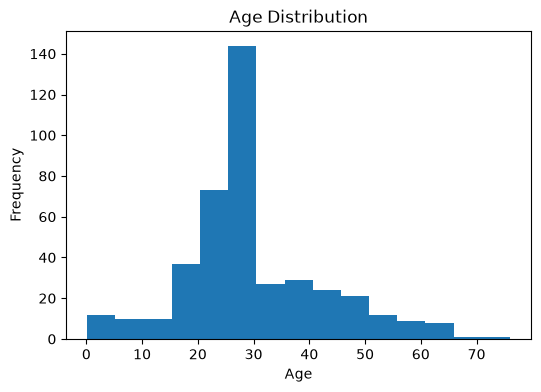

In [6]:
plt.figure(figsize=(6,4))

plt.hist(df["Age"], bins=15)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Interpretation

Most passengers were between 20 and 40 years old. The histogram shows how passenger ages are distributed.

## Visualization 2: Age vs Fare

A scatter plot is used to examine the relationship between passenger age and ticket fare.

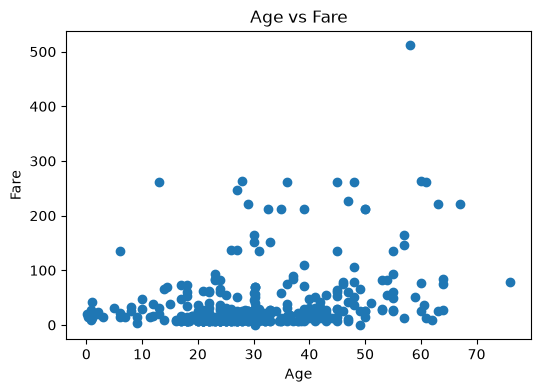

In [7]:
plt.figure(figsize=(6,4))

plt.scatter(df["Age"], df["Fare"])

plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

### Interpretation

The scatter plot shows that there is no strong relationship between passenger age and ticket fare. Most fares are concentrated at lower values.

## Visualization 3: Average Fare by Passenger Class

A bar chart compares the average ticket fare for each passenger class.

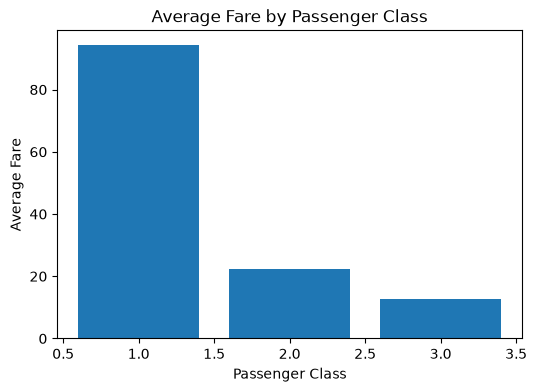

In [8]:
fare = df.groupby("Pclass")["Fare"].mean()

plt.figure(figsize=(6,4))

plt.bar(fare.index, fare.values)

plt.title("Average Fare by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Average Fare")

plt.show()